In [10]:
import numpy as np
import pandas as pd

VERI_YOLU = "../data/UCI HAR Dataset"

def sinyal_yukle(dosya_adi, bolum):
    yol = f"{VERI_YOLU}/{bolum}/Inertial Signals/{dosya_adi}"
    return pd.read_csv(yol, sep=r"\s+", header=None).values

# --- EĞİTİM verisi: artık 6 kanal (3 ivme + 3 jiroskop) ---
acc_x_tr = sinyal_yukle("body_acc_x_train.txt", "train")
acc_y_tr = sinyal_yukle("body_acc_y_train.txt", "train")
acc_z_tr = sinyal_yukle("body_acc_z_train.txt", "train")
gyro_x_tr = sinyal_yukle("body_gyro_x_train.txt", "train")
gyro_y_tr = sinyal_yukle("body_gyro_y_train.txt", "train")
gyro_z_tr = sinyal_yukle("body_gyro_z_train.txt", "train")
y_train = pd.read_csv(f"{VERI_YOLU}/train/y_train.txt", header=None).values.ravel()

# --- TEST verisi: aynı 6 kanal ---
acc_x_te = sinyal_yukle("body_acc_x_test.txt", "test")
acc_y_te = sinyal_yukle("body_acc_y_test.txt", "test")
acc_z_te = sinyal_yukle("body_acc_z_test.txt", "test")
gyro_x_te = sinyal_yukle("body_gyro_x_test.txt", "test")
gyro_y_te = sinyal_yukle("body_gyro_y_test.txt", "test")
gyro_z_te = sinyal_yukle("body_gyro_z_test.txt", "test")
y_test = pd.read_csv(f"{VERI_YOLU}/test/y_test.txt", header=None).values.ravel()

# 6 ekseni birleştir: her örnek artık (128 zaman adımı, 6 kanal)
X_train = np.stack([acc_x_tr, acc_y_tr, acc_z_tr, gyro_x_tr, gyro_y_tr, gyro_z_tr], axis=-1)
X_test  = np.stack([acc_x_te, acc_y_te, acc_z_te, gyro_x_te, gyro_y_te, gyro_z_te], axis=-1)

# Etiketleri 0'dan başlat (1-6 → 0-5)
y_train_0 = y_train - 1
y_test_0  = y_test - 1

print("X_train şekli:", X_train.shape)   # (7352, 128, 6) bekliyoruz
print("X_test şekli:", X_test.shape)     # (2947, 128, 6)

X_train şekli: (7352, 128, 6)
X_test şekli: (2947, 128, 6)


In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape=(128, 6)),          # 6 kanal (3 ivme + 3 jiroskop)

    layers.Conv1D(16, 3, activation="relu"),
    layers.MaxPooling1D(2),
    layers.Conv1D(32, 3, activation="relu"),
    layers.MaxPooling1D(2),

    layers.GlobalAveragePooling1D(),      # Flatten yerine (küçültür + genelleştirir)
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(6, activation="softmax")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 126, 16)        │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 63, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 61, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,126 (12.21 KB)

 Trainable params: 3,126 (12.21 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Erken durdurma: test doğruluğu artık iyileşmiyorsa boşuna eğitme,
# ve en iyi haldeki ağırlıkları geri yükle
erken_durdur = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,                  # 8 epoch boyunca iyileşme yoksa dur
    restore_best_weights=True    # en iyi noktaya geri dön
)

gecmis = model.fit(
    X_train, y_train_0,
    epochs=80,
    batch_size=64,
    validation_data=(X_test, y_test_0),
    callbacks=[erken_durdur],
    verbose=1
)

# Sonuç özeti
en_iyi = max(gecmis.history["val_accuracy"])
print(f"\nEn iyi test doğruluğu: {en_iyi:.4f}  ({en_iyi*100:.1f}%)")

Epoch 1/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3353 - loss: 1.5486 - val_accuracy: 0.4506 - val_loss: 1.3400
Epoch 2/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4187 - loss: 1.1939 - val_accuracy: 0.4852 - val_loss: 1.0439
Epoch 3/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5063 - loss: 0.9910 - val_accuracy: 0.5772 - val_loss: 0.8919
Epoch 4/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5661 - loss: 0.8607 - val_accuracy: 0.6183 - val_loss: 0.7928
Epoch 5/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5975 - loss: 0.7776 - val_accuracy: 0.6189 - val_loss: 0.7386
Epoch 6/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6118 - loss: 0.7286 - val_accuracy: 0.6284 - val_loss: 0.7211
Epoch 7/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6190 - loss: 0.7021 - val_accuracy: 0.6200 - val_loss: 0.7135
Epoch 8/80
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6372 - loss: 0.6765 - val_accuracy: 0.

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


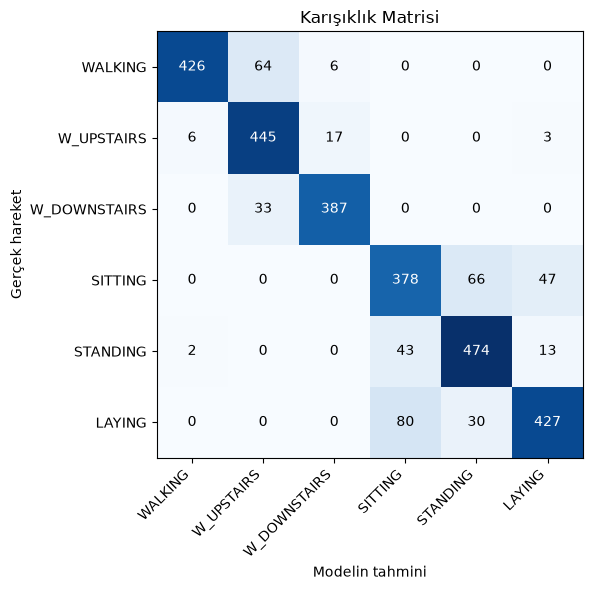

              precision    recall  f1-score   support

     WALKING       0.98      0.86      0.92       496
  W_UPSTAIRS       0.82      0.94      0.88       471
W_DOWNSTAIRS       0.94      0.92      0.93       420
     SITTING       0.75      0.77      0.76       491
    STANDING       0.83      0.89      0.86       532
      LAYING       0.87      0.80      0.83       537

    accuracy                           0.86      2947
   macro avg       0.87      0.86      0.86      2947
weighted avg       0.87      0.86      0.86      2947



In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Test verisinde tahmin yap
tahminler = model.predict(X_test)
tahmin_sinif = np.argmax(tahminler, axis=1)   # en yüksek olasılıklı sınıf

# Hareket isimleri
hareket_isimleri = ["WALKING", "W_UPSTAIRS", "W_DOWNSTAIRS", "SITTING", "STANDING", "LAYING"]

# Karışıklık matrisi
cm = confusion_matrix(y_test_0, tahmin_sinif)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(hareket_isimleri, rotation=45, ha="right")
ax.set_yticklabels(hareket_isimleri)
ax.set_xlabel("Modelin tahmini")
ax.set_ylabel("Gerçek hareket")
ax.set_title("Karışıklık Matrisi")

# Her kutuya sayıyı yaz
for i in range(6):
    for j in range(6):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

# Sınıf bazında detaylı rapor
print(classification_report(y_test_0, tahmin_sinif, target_names=hareket_isimleri))

In [14]:
model.save("../model/hareket_modeli.keras")
print("Model kaydedildi: model/hareket_modeli.keras")

Model kaydedildi: model/hareket_modeli.keras
